Google Colab Lab Assignment
Course Name: DEEP LEARNING



Student Name: Aarya Malghe

Student ID: 202301100061

Date of Submission: 09-04-26

Group Members:  Harsh Kumar,
              Ayush Chandekar,
               Sanket Rath

Github Link: https://github.com/aaarya2809/DL_Assignments/tree/main/Assignment_4

In [1]:
# === 1. Setup & Imports (Improved) ===

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

# NLP Libraries
import nltk

# Download required resources (cleaner approach)
nltk_packages = [
    'punkt', 'stopwords', 'wordnet',
    'averaged_perceptron_tagger', 'punkt_tab' # Added 'punkt_tab'
]

for pkg in nltk_packages:
    nltk.download(pkg, quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

# ML Libraries
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("✅ All imports loaded successfully")

✅ All imports loaded successfully


In [2]:
# === 2. Load Dataset (Improved with Error Handling) ===

def load_dataset(url):
    try:
        df = pd.read_csv(url, sep='\t', header=None, names=['label', 'message'])
        print("✅ Dataset loaded successfully")
        return df
    except Exception as e:
        print("❌ Error loading dataset:", e)
        return None


url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
df = load_dataset(url)

# Basic Info
print("\n--- Dataset Summary ---")
print(f"Total messages : {len(df)}")
print(f"Spam messages  : {df[df['label'] == 'spam'].shape[0]}")
print(f"Ham messages   : {df[df['label'] == 'ham'].shape[0]}")

✅ Dataset loaded successfully

--- Dataset Summary ---
Total messages : 5572
Spam messages  : 747
Ham messages   : 4825


In [3]:
# === 3. Feature Engineering ===

df['char_count'] = df['message'].apply(len)
df['word_count'] = df['message'].apply(lambda x: len(x.split()))
df['digit_count'] = df['message'].apply(lambda x: sum(c.isdigit() for c in x))
df['upper_count'] = df['message'].apply(lambda x: sum(c.isupper() for c in x))

print("\n✅ Feature Engineering Done")
print(df.head())


✅ Feature Engineering Done
  label                                            message  char_count  \
0   ham  Go until jurong point, crazy.. Available only ...         111   
1   ham                      Ok lar... Joking wif u oni...          29   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...         155   
3   ham  U dun say so early hor... U c already then say...          49   
4   ham  Nah I don't think he goes to usf, he lives aro...          61   

   word_count  digit_count  upper_count  
0          20            0            3  
1           6            0            2  
2          28           25           10  
3          11            0            2  
4          13            0            2  


In [4]:
# === 4. Enhanced Exploratory Data Analysis ===

print("Dataset Shape:", df.shape)

# --- Label Distribution ---
print("\nLabel distribution:")
print(df['label'].value_counts(normalize=True) * 100)

# --- Advanced Feature Engineering ---
df['msg_length'] = df['message'].apply(len)
df['word_count'] = df['message'].apply(lambda x: len(x.split()))
df['avg_word_length'] = df['msg_length'] / (df['word_count'] + 1)
df['digit_count'] = df['message'].apply(lambda x: sum(c.isdigit() for c in x))
df['special_char_count'] = df['message'].apply(lambda x: sum(not c.isalnum() for c in x))

# --- Statistical Summary ---
print("\n📊 Statistical Summary:")
print(df.groupby('label')[['msg_length', 'word_count', 'digit_count']].mean().round(2))

# --- Top Words in Spam vs Ham ---
from collections import Counter

def get_top_words(text_series, n=10):
    all_words = " ".join(text_series).split()
    return Counter(all_words).most_common(n)

print("\n🔥 Top words in SPAM:")
print(get_top_words(df[df['label']=='spam']['message']))

print("\n🔥 Top words in HAM:")
print(get_top_words(df[df['label']=='ham']['message']))

Dataset Shape: (5572, 6)

Label distribution:
label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64

📊 Statistical Summary:
       msg_length  word_count  digit_count
label                                     
ham         71.48       14.31         0.31
spam       138.67       23.91        15.81

🔥 Top words in SPAM:
[('to', 607), ('a', 360), ('your', 187), ('call', 185), ('or', 185), ('the', 178), ('2', 169), ('for', 169), ('you', 164), ('is', 143)]

🔥 Top words in HAM:
[('to', 1538), ('you', 1462), ('I', 1439), ('the', 1029), ('a', 977), ('i', 742), ('and', 739), ('in', 736), ('u', 651), ('is', 645)]


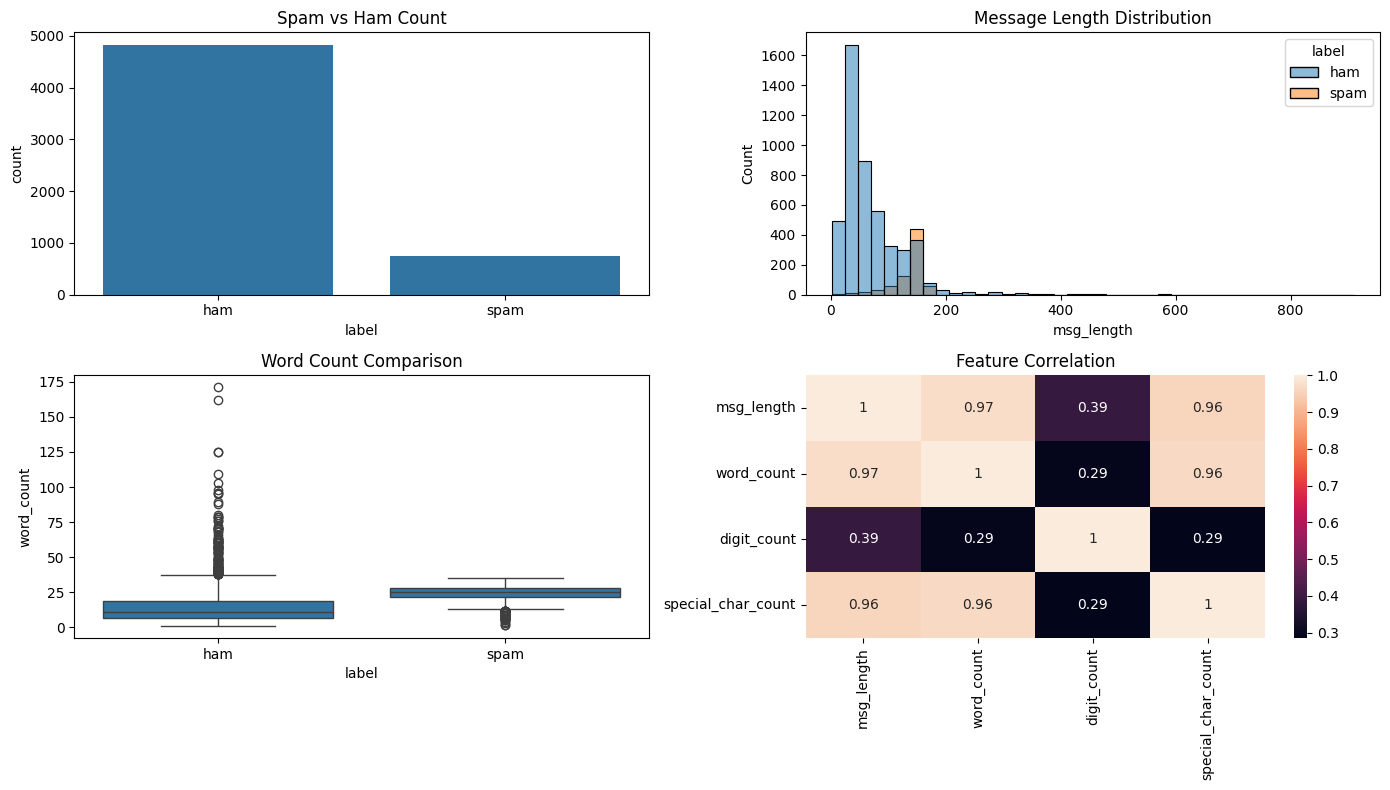

In [5]:
# === Visualization Section ===

plt.figure(figsize=(14,8))

# 1. Label Distribution
plt.subplot(2,2,1)
sns.countplot(x='label', data=df)
plt.title("Spam vs Ham Count")

# 2. Message Length Distribution
plt.subplot(2,2,2)
sns.histplot(data=df, x='msg_length', hue='label', bins=40)
plt.title("Message Length Distribution")

# 3. Word Count Boxplot
plt.subplot(2,2,3)
sns.boxplot(x='label', y='word_count', data=df)
plt.title("Word Count Comparison")

# 4. Correlation Heatmap (NEW 🔥)
plt.subplot(2,2,4)
corr = df[['msg_length','word_count','digit_count','special_char_count']].corr()
sns.heatmap(corr, annot=True)
plt.title("Feature Correlation")

plt.tight_layout()
plt.savefig('advanced_eda.png', dpi=120)
plt.show()

#NLP Preprocessing From Scratch

In [6]:
# === Advanced Manual NLP Preprocessing (From Scratch) ===

# --- Step 1: Smarter Tokenizer ---
def manual_tokenize(text):
    text = text.lower()

    # replace punctuation with space
    for ch in string.punctuation:
        text = text.replace(ch, ' ')

    tokens = []
    for word in text.split():
        # remove tokens with only numbers or very short tokens
        if word.isdigit():
            continue
        if len(word) <= 2:
            continue
        tokens.append(word)

    return tokens

In [7]:
# --- Step 2: Improved Stopwords ---
# Added more realistic stopwords (important for NLP quality)

MANUAL_STOPWORDS = set([
    'i','me','my','myself','we','our','ours','you','your','yours',
    'he','him','his','she','her','it','its','they','them','their',
    'what','which','who','this','that','these','those',
    'am','is','are','was','were','be','been','being',
    'have','has','had','do','does','did',
    'will','would','should','can','could','may','might',
    'a','an','the','and','but','if','or','because','as',
    'of','at','by','for','with','about','to','from','in','on','up',
    'so','than','too','very','just','now','only'
])

def manual_remove_stopwords(tokens):
    return [word for word in tokens if word not in MANUAL_STOPWORDS]

In [8]:
# --- Step 3: Smarter Stemming (Improved Rules) ---

def manual_stem(word):
    suffixes = ['ization','ational','fulness','ousness','iveness',
                'tion','ing','edly','edly','ed','ly','er','es','s']

    for suffix in suffixes:
        if word.endswith(suffix) and len(word) - len(suffix) >= 3:
            return word[:-len(suffix)]

    return word


def manual_stem_tokens(tokens):
    return [manual_stem(word) for word in tokens]

In [9]:
# --- Step 4: NEW Feature Extraction (🔥 BIG UPGRADE) ---

def extract_manual_features(text):
    return {
        "has_number": int(any(c.isdigit() for c in text)),
        "has_uppercase": int(any(c.isupper() for c in text)),
        "has_exclamation": int("!" in text),
        "has_url": int("http" in text or "www" in text)
    }

In [10]:
# --- Step 5: Full Pipeline ---

def manual_preprocess(text):
    tokens = manual_tokenize(text)
    tokens = manual_remove_stopwords(tokens)
    tokens = manual_stem_tokens(tokens)
    return ' '.join(tokens)

In [11]:
# --- Step 6: Testing (Better Output Display) ---

test_messages = [
    "Congratulations! You've won a FREE iPhone. Click here to claim your prize!",
    "Hey, are we still meeting for lunch tomorrow at noon?",
    "URGENT: Your bank account has been compromised. Verify your details NOW!"
]

print("🚀 Advanced Manual NLP Pipeline")
print("=" * 60)

for msg in test_messages:
    processed = manual_preprocess(msg)
    features = extract_manual_features(msg)

    print(f"\nOriginal  : {msg}")
    print(f"Processed : {processed}")
    print(f"Features  : {features}")

🚀 Advanced Manual NLP Pipeline

Original  : Congratulations! You've won a FREE iPhone. Click here to claim your prize!
Processed : congratulation won free iphone click here claim prize
Features  : {'has_number': 0, 'has_uppercase': 1, 'has_exclamation': 1, 'has_url': 0}

Original  : Hey, are we still meeting for lunch tomorrow at noon?
Processed : hey still meet lunch tomorrow noon
Features  : {'has_number': 0, 'has_uppercase': 1, 'has_exclamation': 0, 'has_url': 0}

Original  : URGENT: Your bank account has been compromised. Verify your details NOW!
Processed : urgent bank account compromis verify detail
Features  : {'has_number': 0, 'has_uppercase': 1, 'has_exclamation': 1, 'has_url': 0}


In [12]:
# --- Step 7: Apply to Dataset ---

print("\nApplying advanced manual preprocessing...")

df['manual_processed'] = df['message'].apply(manual_preprocess)

# Extract additional manual features
feature_df = df['message'].apply(lambda x: pd.Series(extract_manual_features(x)))

df = pd.concat([df, feature_df], axis=1)

print("✅ Done")

print("\nSample Output:")
print(df[['message', 'manual_processed', 'has_number', 'has_exclamation']].head(3))


Applying advanced manual preprocessing...
✅ Done

Sample Output:
                                             message  \
0  Go until jurong point, crazy.. Available only ...   
1                      Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup fina...   

                                    manual_processed  has_number  \
0  until jurong point crazy available bugi great ...           0   
1                                    lar jok wif oni           0   
2  free entry wkly comp win cup final tkt 21st te...           1   

   has_exclamation  
0                0  
1                0  
2                0  


#NLP Preprocessing Using Libraries

In [13]:
# === Advanced NLP Preprocessing using NLTK ===

from nltk import pos_tag
from nltk.corpus import wordnet

stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# --- POS Tag Conversion (VERY IMPORTANT UPGRADE) ---
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

In [14]:
# --- Advanced Preprocessing Pipeline ---

def advanced_library_preprocess(text, use_stemming=False):

    # Step 1: Lowercase
    text = text.lower()

    # Step 2: Remove punctuation & numbers
    text = re.sub(r'[^a-z\s]', '', text)

    # Step 3: Tokenization
    tokens = word_tokenize(text)

    # Step 4: Stopword removal
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]

    # Step 5: POS tagging (NEW 🔥)
    pos_tags = pos_tag(tokens)

    # Step 6: Lemmatization using POS
    lemmatized = [
        lemmatizer.lemmatize(word, get_wordnet_pos(tag))
        for word, tag in pos_tags
    ]

    # Step 7: Optional stemming
    if use_stemming:
        lemmatized = [stemmer.stem(word) for word in lemmatized]

    return " ".join(lemmatized)

In [15]:
# --- Extra Feature Extraction (Spam Indicators 🔥) ---

def extract_advanced_features(text):
    return {
        "length": len(text),
        "num_digits": sum(c.isdigit() for c in text),
        "num_caps": sum(c.isupper() for c in text),
        "num_special": sum(not c.isalnum() for c in text),
        "has_link": int("http" in text or "www" in text),
        "has_money": int("£" in text or "$" in text)
    }

In [16]:
# === Robust NLTK Downloads ===

nltk_packages = [
    'punkt',
    'stopwords',
    'wordnet',
    'averaged_perceptron_tagger',
    'averaged_perceptron_tagger_eng'   # important fix
]

for pkg in nltk_packages:
    try:
        nltk.download(pkg, quiet=True)
    except:
        print(f"Skipping {pkg}")

In [17]:
# --- Apply to Dataset (Optimized) ---

print("Applying advanced NLP preprocessing...")

df['processed_advanced'] = df['message'].apply(advanced_library_preprocess)

# Add features
feature_df = df['message'].apply(lambda x: pd.Series(extract_advanced_features(x)))
df = pd.concat([df, feature_df], axis=1)

print("✅ Done")

Applying advanced NLP preprocessing...
✅ Done


In [18]:
# --- Improved Comparison Output ---

print("\n🔍 Comparison (Manual vs Advanced NLP)")
print("=" * 70)

for i in range(3):
    print(f"\nOriginal   : {df['message'][i][:80]}")
    print(f"Manual     : {df['manual_processed'][i][:80]}")
    print(f"NLTK Adv   : {df['processed_advanced'][i][:80]}")


🔍 Comparison (Manual vs Advanced NLP)

Original   : Go until jurong point, crazy.. Available only in bugis n great world la e buffet
Manual     : until jurong point crazy available bugi great world buffet cine there got amore 
NLTK Adv   : jurong point crazy available bugis great world buffet cine get amore wat

Original   : Ok lar... Joking wif u oni...
Manual     : lar jok wif oni
NLTK Adv   : lar joking wif oni

Original   : Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 8
Manual     : free entry wkly comp win cup final tkt 21st text receive entry ques std txt rate
NLTK Adv   : free entry wkly comp win cup final tkts may text receive entry questionstd txt r


#POS Tagging

In [19]:
# === Improved Scratch POS Tagger ===

def improved_scratch_pos_tagger(tokens):
    tagged = []

    for i, word in enumerate(tokens):
        if word in ['is','are','was','were','be','been','am','have','has','do','does']:
            tag = 'VB'
        elif word.endswith('ing'):
            tag = 'VBG'
        elif word.endswith('ed'):
            tag = 'VBD'
        elif word.endswith('ly'):
            tag = 'RB'
        elif word.endswith(('ous','ful','able','ive')):
            tag = 'JJ'
        elif word.endswith(('tion','ness','ment')):
            tag = 'NN'
        elif word.isdigit():
            tag = 'CD'
        elif len(word) <= 2:
            tag = 'IN'  # preposition/determiner approx
        else:
            tag = 'NN'

        tagged.append((word, tag))

    return tagged

In [20]:
from nltk import pos_tag
from nltk.tokenize import word_tokenize
from collections import Counter

def get_pos_distribution(text_series):
    pos_counts = Counter()

    for text in text_series:
        tokens = word_tokenize(text)
        tags = pos_tag(tokens)

        for _, tag in tags:
            pos_counts[tag[:2]] += 1   # group like NN, VB, JJ

    return pos_counts


# Separate spam and ham
spam_texts = df[df['label']=='spam']['message']
ham_texts  = df[df['label']=='ham']['message']

spam_pos_dist = get_pos_distribution(spam_texts[:200])  # limit for speed
ham_pos_dist  = get_pos_distribution(ham_texts[:200])

print("Spam POS Distribution:", spam_pos_dist)
print("Ham POS Distribution :", ham_pos_dist)

Spam POS Distribution: Counter({'NN': 1970, 'VB': 635, 'CD': 606, '.': 477, 'JJ': 375, 'IN': 300, 'PR': 214, 'DT': 197, 'TO': 182, 'RB': 148, 'CC': 147, ',': 101, ':': 63, 'MD': 27, 'PO': 24, 'WP': 22, 'RP': 20, '(': 17, ')': 17, "''": 7, '$': 6, 'FW': 5, 'WR': 5, 'EX': 4, '``': 3, '#': 3, 'UH': 2, 'WD': 2, 'SY': 2, 'PD': 2})
Ham POS Distribution : Counter({'NN': 874, 'VB': 649, 'PR': 396, '.': 286, 'IN': 243, 'RB': 231, 'JJ': 217, 'DT': 133, ':': 98, 'CC': 96, 'TO': 64, ',': 60, 'MD': 56, 'WR': 35, 'CD': 29, ')': 19, 'RP': 18, 'PO': 13, 'UH': 13, 'WP': 11, '#': 10, 'WD': 6, "''": 6, '``': 5, 'EX': 4, 'PD': 4, 'FW': 3, '(': 3, '$': 3})


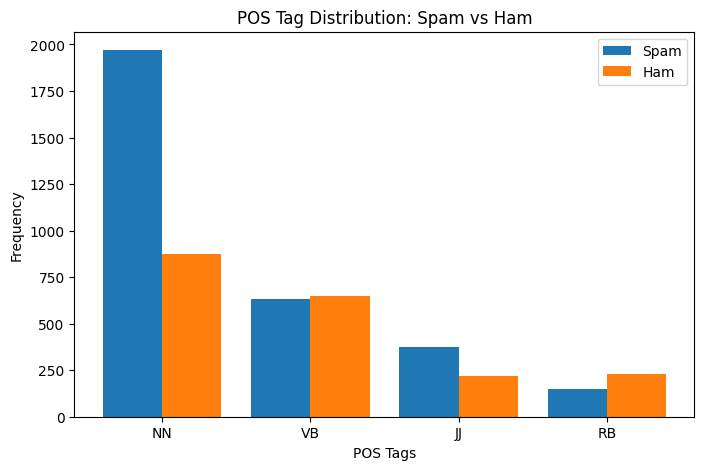

In [21]:
# === POS Comparison Plot ===

common_tags = ['NN','VB','JJ','RB']

spam_values = [spam_pos_dist.get(tag,0) for tag in common_tags]
ham_values  = [ham_pos_dist.get(tag,0) for tag in common_tags]

x = range(len(common_tags))

plt.figure(figsize=(8,5))

plt.bar(x, spam_values, width=0.4, label='Spam')
plt.bar([i+0.4 for i in x], ham_values, width=0.4, label='Ham')

plt.xticks([i+0.2 for i in x], common_tags)
plt.title("POS Tag Distribution: Spam vs Ham")
plt.xlabel("POS Tags")
plt.ylabel("Frequency")
plt.legend()

plt.show()

In [22]:
print("\n📊 POS Comparison Table")
print("-"*40)
print(f"{'POS':<10}{'Spam':<10}{'Ham':<10}")

for tag in common_tags:
    print(f"{tag:<10}{spam_pos_dist.get(tag,0):<10}{ham_pos_dist.get(tag,0):<10}")


📊 POS Comparison Table
----------------------------------------
POS       Spam      Ham       
NN        1970      874       
VB        635       649       
JJ        375       217       
RB        148       231       


# Named Entity Recognition (NER)

In [23]:
# === Improved Scratch NER ===

def improved_scratch_ner(tokens):
    entities = []

    org_keywords    = ['nokia','vodafone','google','facebook','amazon','paypal']
    person_titles   = ['mr','mrs','miss','dr','sir']
    place_keywords  = ['london','uk','usa','india','california']

    i = 0
    while i < len(tokens):
        word = tokens[i].lower()

        # MONEY (more flexible)
        if any(sym in word for sym in ['£','$','rs']):
            entities.append((tokens[i], 'MONEY'))

        # PHONE / LARGE NUMBER
        elif word.isdigit() and len(word) >= 5:
            entities.append((tokens[i], 'NUMBER'))

        # DATE (extended)
        elif word in ['jan','feb','march','april','may','june','july',
                      'aug','sep','oct','nov','dec']:
            entities.append((tokens[i], 'DATE'))

        # PERSON (title + name)
        elif word in person_titles and i+1 < len(tokens):
            entities.append((tokens[i] + ' ' + tokens[i+1], 'PERSON'))
            i += 1

        # ORG
        elif word in org_keywords:
            entities.append((tokens[i], 'ORG'))

        # PLACE
        elif word in place_keywords:
            entities.append((tokens[i], 'GPE'))

        i += 1

    return entities

In [24]:
import spacy

# Load model (run once)
nlp = spacy.load("en_core_web_sm")

def spacy_ner(text):
    doc = nlp(text)
    return [(ent.text, ent.label_) for ent in doc.ents]

In [25]:
from collections import Counter

def get_entity_distribution(text_series, ner_function, limit=200):
    entity_counts = Counter()

    # convert to list (important for slicing safely)
    texts = list(text_series)[:limit]

    for text in texts:
        entities = ner_function(text)

        for _, label in entities:
            entity_counts[label] += 1

    return entity_counts

In [26]:
# Separate spam & ham
spam_texts = df[df['label']=='spam']['message']
ham_texts  = df[df['label']=='ham']['message']

# Compute distributions
spam_entities = get_entity_distribution(spam_texts, spacy_ner)
ham_entities  = get_entity_distribution(ham_texts, spacy_ner)

print("Spam Entity Distribution:", spam_entities)
print("Ham Entity Distribution :", ham_entities)

Spam Entity Distribution: Counter({'CARDINAL': 223, 'DATE': 213, 'ORG': 143, 'PERSON': 79, 'MONEY': 71, 'GPE': 24, 'NORP': 10, 'PRODUCT': 8, 'QUANTITY': 5, 'EVENT': 4, 'TIME': 4, 'WORK_OF_ART': 4, 'ORDINAL': 3, 'FAC': 3, 'LAW': 2, 'LANGUAGE': 1})
Ham Entity Distribution : Counter({'PERSON': 31, 'ORG': 24, 'DATE': 21, 'CARDINAL': 19, 'TIME': 12, 'GPE': 7, 'ORDINAL': 7, 'WORK_OF_ART': 3, 'PRODUCT': 2, 'QUANTITY': 2, 'LOC': 1, 'NORP': 1, 'MONEY': 1, 'LANGUAGE': 1, 'FAC': 1})


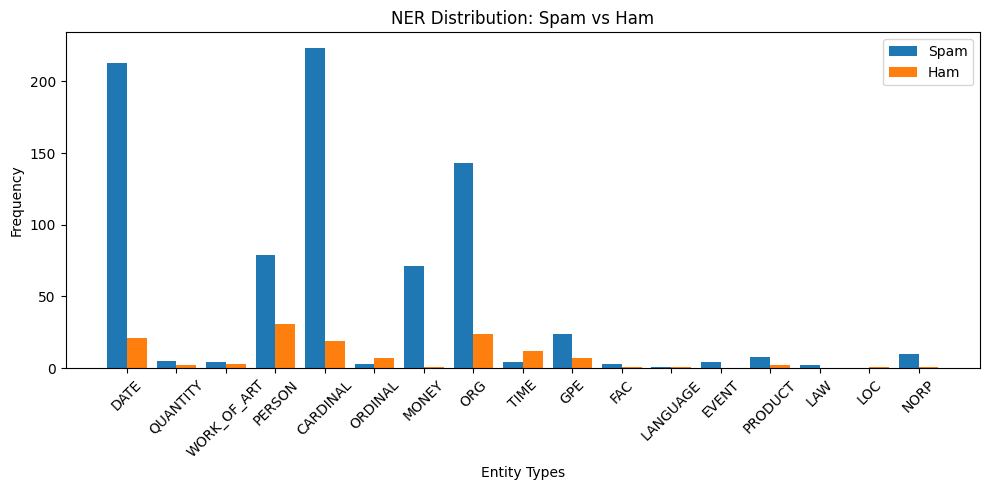

In [27]:
# === Entity Comparison Plot ===

common_entities = list(set(list(spam_entities.keys()) + list(ham_entities.keys())))

spam_vals = [spam_entities.get(ent, 0) for ent in common_entities]
ham_vals  = [ham_entities.get(ent, 0) for ent in common_entities]

x = range(len(common_entities))

plt.figure(figsize=(10,5))

plt.bar(x, spam_vals, width=0.4, label='Spam')
plt.bar([i+0.4 for i in x], ham_vals, width=0.4, label='Ham')

plt.xticks([i+0.2 for i in x], common_entities, rotation=45)
plt.title("NER Distribution: Spam vs Ham")
plt.xlabel("Entity Types")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()

In [28]:
print("\n📊 Entity Comparison Table")
print("-"*50)
print(f"{'Entity':<15}{'Spam':<10}{'Ham':<10}")

for ent in common_entities:
    print(f"{ent:<15}{spam_entities.get(ent,0):<10}{ham_entities.get(ent,0):<10}")


📊 Entity Comparison Table
--------------------------------------------------
Entity         Spam      Ham       
DATE           213       21        
QUANTITY       5         2         
WORK_OF_ART    4         3         
PERSON         79        31        
CARDINAL       223       19        
ORDINAL        3         7         
MONEY          71        1         
ORG            143       24        
TIME           4         12        
GPE            24        7         
FAC            3         1         
LANGUAGE       1         1         
EVENT          4         0         
PRODUCT        8         2         
LAW            2         0         
LOC            0         1         
NORP           10        1         


#Text Vectorization

In [29]:
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def library_preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)

    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]

    lemmatized = [lemmatizer.lemmatize(word) for word in tokens]

    return {
        'lemmatized': ' '.join(lemmatized)
    }

In [30]:
processed = df['message'].apply(library_preprocess)

df['lemmatized_processed'] = processed.apply(lambda x: x['lemmatized'])

print("✅ Preprocessing Done")
print(df[['message', 'lemmatized_processed']].head())

✅ Preprocessing Done
                                             message  \
0  Go until jurong point, crazy.. Available only ...   
1                      Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup fina...   
3  U dun say so early hor... U c already then say...   
4  Nah I don't think he goes to usf, he lives aro...   

                                lemmatized_processed  
0  go jurong point crazy available bugis n great ...  
1                            ok lar joking wif u oni  
2  free entry wkly comp win fa cup final tkts st ...  
3                u dun say early hor u c already say  
4           nah dont think go usf life around though  


In [31]:
df['label_encoded'] = df['label'].map({'spam': 1, 'ham': 0})

In [32]:
from sklearn.model_selection import train_test_split

X = df['lemmatized_processed']
y = df['label_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("✅ Train-Test Split Done")

✅ Train-Test Split Done


In [33]:
from sklearn.feature_extraction.text import CountVectorizer

print("\n--- CountVectorizer ---")

cv = CountVectorizer(
    max_features=3000,
    ngram_range=(1,2),
    min_df=2
)

X_train_cv = cv.fit_transform(X_train)
X_test_cv  = cv.transform(X_test)

print("Vocabulary size:", len(cv.vocabulary_))
print("Train shape:", X_train_cv.shape)
print("Test shape:", X_test_cv.shape)


--- CountVectorizer ---
Vocabulary size: 3000
Train shape: (4457, 3000)
Test shape: (1115, 3000)


In [34]:
word_counts = np.asarray(X_train_cv.sum(axis=0)).flatten()
words = cv.get_feature_names_out()

top_idx = word_counts.argsort()[::-1][:15]

print("\nTop 15 frequent words:")
for i in top_idx:
    print(f"{words[i]:<20} : {word_counts[i]}")


Top 15 frequent words:
call                 : 495
im                   : 382
get                  : 311
ur                   : 296
go                   : 247
dont                 : 227
ltgt                 : 225
free                 : 224
got                  : 217
know                 : 216
ok                   : 211
day                  : 210
come                 : 198
ill                  : 197
good                 : 188


In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer

print("\n--- TF-IDF ---")

tfidf = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1,2),
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print("Vocabulary size:", len(tfidf.vocabulary_))
print("Train shape:", X_train_tfidf.shape)
print("Test shape:", X_test_tfidf.shape)


--- TF-IDF ---
Vocabulary size: 3000
Train shape: (4457, 3000)
Test shape: (1115, 3000)


In [36]:
tfidf_scores = np.asarray(X_train_tfidf.mean(axis=0)).flatten()
words = tfidf.get_feature_names_out()

top_idx = tfidf_scores.argsort()[::-1][:15]

print("\nTop 15 TF-IDF words:")
for i in top_idx:
    print(f"{words[i]:<20} : {tfidf_scores[i]:.6f}")


Top 15 TF-IDF words:
call                 : 0.019446
im                   : 0.017844
ok                   : 0.016929
get                  : 0.014495
come                 : 0.012274
ltgt                 : 0.012146
got                  : 0.012059
ill                  : 0.011583
ur                   : 0.011401
dont                 : 0.011328
know                 : 0.011170
go                   : 0.011133
good                 : 0.010520
like                 : 0.010163
time                 : 0.009947


#N-Gram

In [37]:
# N-Grams - All approaches on spam dataset
# N-grams are sequences of N consecutive words
# bigrams = 2 words, trigrams = 3 words
# helps capture phrases like "free entry", "win cash", "click here"

# -----------------------------------------------------------------------
# APPROACH 1:  (no libraries)
# -----------------------------------------------------------------------

def scratch_ngrams(tokens, n):
    # sliding window of size n over the token list
    ngrams = []
    for i in range(len(tokens) - n + 1):
        ngram = tuple(tokens[i:i+n])
        ngrams.append(ngram)
    return ngrams

spam_example = df[df['label'] == 'spam']['message'].iloc[0]
ham_example  = df[df['label'] == 'ham']['message'].iloc[0]

spam_tokens = manual_tokenize(spam_example)
ham_tokens  = manual_tokenize(ham_example)

print("=== FROM SCRATCH N-Grams ===")
print("\nSpam message:", spam_example[:80])
print("Bigrams  :", scratch_ngrams(spam_tokens, 2)[:5])
print("Trigrams :", scratch_ngrams(spam_tokens, 3)[:5])

print("\nHam message:", ham_example[:80])
print("Bigrams  :", scratch_ngrams(ham_tokens, 2)[:5])
print("Trigrams :", scratch_ngrams(ham_tokens, 3)[:5])

# -----------------------------------------------------------------------
# APPROACH 2: WITH LIBRARY (nltk)
# -----------------------------------------------------------------------
from nltk import ngrams, word_tokenize, FreqDist

print("\n=== WITH LIBRARY (NLTK) N-Grams ===")

# collect all tokens from spam and ham separately
spam_all_tokens = []
ham_all_tokens  = []

for msg in df[df['label'] == 'spam']['message']:
    spam_all_tokens.extend(word_tokenize(str(msg).lower()))

for msg in df[df['label'] == 'ham']['message']:
    ham_all_tokens.extend(word_tokenize(str(msg).lower()))

spam_bigrams  = list(ngrams(spam_all_tokens, 2))
ham_bigrams   = list(ngrams(ham_all_tokens,  2))
spam_trigrams = list(ngrams(spam_all_tokens, 3))
ham_trigrams  = list(ngrams(ham_all_tokens,  3))

spam_bigram_freq  = FreqDist(spam_bigrams)
ham_bigram_freq   = FreqDist(ham_bigrams)
spam_trigram_freq = FreqDist(spam_trigrams)
ham_trigram_freq  = FreqDist(ham_trigrams)

print("\nTop 5 Bigrams in SPAM:")
for gram, count in spam_bigram_freq.most_common(5):
    print(f"  {gram}  ->  {count}")

print("\nTop 5 Bigrams in HAM:")
for gram, count in ham_bigram_freq.most_common(5):
    print(f"  {gram}  ->  {count}")

print("\nTop 5 Trigrams in SPAM:")
for gram, count in spam_trigram_freq.most_common(5):
    print(f"  {gram}  ->  {count}")

print("\nTop 5 Trigrams in HAM:")
for gram, count in ham_trigram_freq.most_common(5):
    print(f"  {gram}  ->  {count}")

# -----------------------------------------------------------------------
# APPROACH 3: EXISTING MODEL (sklearn CountVectorizer with ngram_range)
# -----------------------------------------------------------------------
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

print("\n=== EXISTING MODEL (sklearn) N-Grams ===")

# bigram vectorizer
bigram_vec = CountVectorizer(ngram_range=(2, 2), max_features=10)
bigram_vec.fit(df['message'])

# get top bigrams from spam messages only
spam_text  = df[df['label'] == 'spam']['message']
ham_text   = df[df['label'] == 'ham']['message']

spam_bigram_matrix = bigram_vec.transform(spam_text).toarray().sum(axis=0)
ham_bigram_matrix  = bigram_vec.transform(ham_text).toarray().sum(axis=0)

feature_names = bigram_vec.get_feature_names_out()

print("\nTop Bigrams - Spam vs Ham count (sklearn):")
print(f"{'Bigram':<30} {'Spam count':<15} {'Ham count'}")
print("-" * 55)
for i, bigram in enumerate(feature_names):
    print(f"{bigram:<30} {spam_bigram_matrix[i]:<15} {ham_bigram_matrix[i]}")

=== FROM SCRATCH N-Grams ===

Spam message: Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 8
Bigrams  : [('free', 'entry'), ('entry', 'wkly'), ('wkly', 'comp'), ('comp', 'win'), ('win', 'cup')]
Trigrams : [('free', 'entry', 'wkly'), ('entry', 'wkly', 'comp'), ('wkly', 'comp', 'win'), ('comp', 'win', 'cup'), ('win', 'cup', 'final')]

Ham message: Go until jurong point, crazy.. Available only in bugis n great world la e buffet
Bigrams  : [('until', 'jurong'), ('jurong', 'point'), ('point', 'crazy'), ('crazy', 'available'), ('available', 'only')]
Trigrams : [('until', 'jurong', 'point'), ('jurong', 'point', 'crazy'), ('point', 'crazy', 'available'), ('crazy', 'available', 'only'), ('available', 'only', 'bugis')]

=== WITH LIBRARY (NLTK) N-Grams ===

Top 5 Bigrams in SPAM:
  ('.', 'call')  ->  88
  ('now', '!')  ->  81
  ('you', 'have')  ->  73
  ('*', '*')  ->  61
  ('have', 'won')  ->  54

Top 5 Bigrams in HAM:
  ('.', 'i')  ->  504
  ('i', "'m")  ->  384


In [38]:
from nltk import ngrams, FreqDist
from nltk.tokenize import word_tokenize

print("\n=== NLTK N-Grams (Improved) ===")

def get_top_ngrams(text_series, n=2, top_k=5):
    all_tokens = []

    for msg in text_series:
        tokens = word_tokenize(str(msg).lower())
        all_tokens.extend(tokens)

    n_grams = list(ngrams(all_tokens, n))
    freq = FreqDist(n_grams)

    return freq.most_common(top_k)


# Top n-grams
print("\nTop Bigrams (Spam):", get_top_ngrams(df[df['label']=='spam']['message'], 2))
print("Top Bigrams (Ham) :", get_top_ngrams(df[df['label']=='ham']['message'], 2))

print("\nTop Trigrams (Spam):", get_top_ngrams(df[df['label']=='spam']['message'], 3))
print("Top Trigrams (Ham) :", get_top_ngrams(df[df['label']=='ham']['message'], 3))


=== NLTK N-Grams (Improved) ===

Top Bigrams (Spam): [(('.', 'call'), 88), (('now', '!'), 81), (('you', 'have'), 73), (('*', '*'), 61), (('have', 'won'), 54)]
Top Bigrams (Ham) : [(('.', 'i'), 504), (('i', "'m"), 384), (('&', 'lt'), 314), (('lt', ';'), 314), (('&', 'gt'), 314)]

Top Trigrams (Spam): [(('*', '*', '*'), 51), (('you', 'have', 'won'), 37), (('have', 'won', 'a'), 33), (('t', '&', 'c'), 24), (('t', '&', 'cs'), 21)]
Top Trigrams (Ham) : [(('&', 'lt', ';'), 314), (('&', 'gt', ';'), 314), (('lt', ';', '#'), 276), ((';', '#', '&'), 276), (('#', '&', 'gt'), 276)]


In [39]:
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

print("\n=== Sklearn N-Grams ===")

text_data = df['lemmatized_processed']

vectorizer = CountVectorizer(
    ngram_range=(2,2),
    max_features=20,
    min_df=2
)

X = vectorizer.fit_transform(text_data)
features = vectorizer.get_feature_names_out()

spam_indices = np.where(df['label'] == 'spam')[0]
ham_indices  = np.where(df['label'] == 'ham')[0]

spam_counts = np.asarray(X[spam_indices].sum(axis=0)).flatten()
ham_counts  = np.asarray(X[ham_indices].sum(axis=0)).flatten()

print(f"\n{'Bigram':<30}{'Spam':<10}{'Ham':<10}")
print("-"*50)

for i in range(len(features)):
    print(f"{features[i]:<30}{spam_counts[i]:<10}{ham_counts[i]:<10}")


=== Sklearn N-Grams ===

Bigram                        Spam      Ham       
--------------------------------------------------
call landline                 23        2         
call later                    0         52        
customer service              27        2         
dont know                     6         33        
every week                    19        2         
gon na                        0         58        
good morning                  0         31        
guaranteed call               23        0         
ill call                      0         48        
im going                      0         26        
let know                      0         42        
new year                      2         30        
ok lor                        0         22        
please call                   46        9         
pls send                      0         22        
po box                        31        1         
prize guaranteed              22        0         
sorry

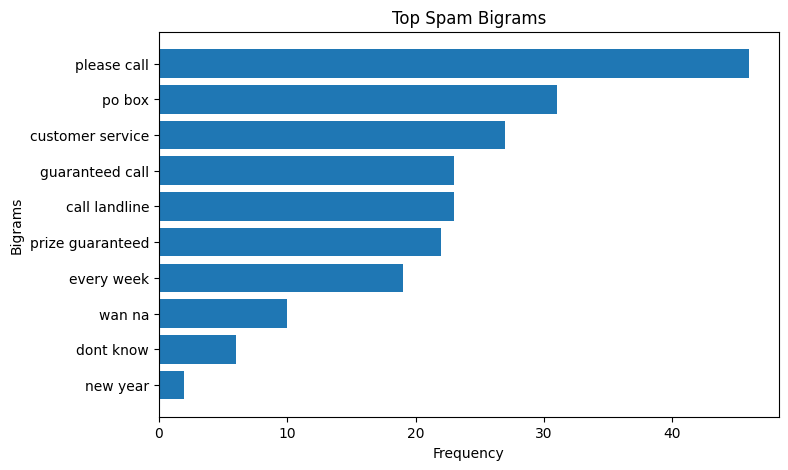

In [40]:
import matplotlib.pyplot as plt

top_idx = spam_counts.argsort()[::-1][:10]

top_words = [features[i] for i in top_idx]
top_values = [spam_counts[i] for i in top_idx]

plt.figure(figsize=(8,5))
plt.barh(top_words[::-1], top_values[::-1])
plt.title("Top Spam Bigrams")
plt.xlabel("Frequency")
plt.ylabel("Bigrams")
plt.show()

In [41]:
print("\n🔥 Top Spam Trigger Bigrams:")

for i in top_idx:
    print(f"{features[i]} → {spam_counts[i]}")


🔥 Top Spam Trigger Bigrams:
please call → 46
po box → 31
customer service → 27
guaranteed call → 23
call landline → 23
prize guaranteed → 22
every week → 19
wan na → 10
dont know → 6
new year → 2


#Word Embeddings

In [42]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 45.3 MB/s eta 0:00:00


In [43]:
# === BLOCK 1: Co-occurrence Matrix (From Scratch) ===
# Idea: words that appear together frequently have similar meaning

import numpy as np

def build_cooccurrence(corpus, window=2):
    # Step 1: Build vocabulary (word → index)
    vocab = {}
    idx = 0
    for sentence in corpus:
        for word in sentence:
            if word not in vocab:
                vocab[word] = idx
                idx += 1

    # Step 2: Initialize co-occurrence matrix
    V = len(vocab)
    matrix = np.zeros((V, V))

    # Step 3: Fill matrix using sliding window
    for sentence in corpus:
        for i, word in enumerate(sentence):
            start = max(0, i - window)
            end   = min(len(sentence), i + window + 1)

            for j in range(start, end):
                if i != j:
                    w1 = vocab[word]
                    w2 = vocab[sentence[j]]
                    matrix[w1][w2] += 1

    return vocab, matrix


# Cosine similarity between vectors
def cosine_sim_scratch(v1, v2):
    dot  = np.dot(v1, v2)
    norm = np.linalg.norm(v1) * np.linalg.norm(v2)
    return dot / norm if norm != 0 else 0


# Use small subset (for speed)
subset = df['message'].head(500).tolist()
tokenized = [manual_tokenize(str(msg)) for msg in subset]

print("=== Co-occurrence Embeddings ===")
vocab, cooc_matrix = build_cooccurrence(tokenized)

print("Vocabulary size:", len(vocab))
print("Matrix shape:", cooc_matrix.shape)

=== Co-occurrence Embeddings ===
Vocabulary size: 1909
Matrix shape: (1909, 1909)


In [44]:
# === BLOCK 2: Similarity Check ===

pairs = [('free', 'win'), ('free', 'call'), ('call', 'now'), ('go', 'come')]

print("\nCo-occurrence Similarity:")

for w1, w2 in pairs:
    if w1 in vocab and w2 in vocab:
        sim = cosine_sim_scratch(cooc_matrix[vocab[w1]], cooc_matrix[vocab[w2]])
        print(f"{w1:<10} <-> {w2:<10} : {sim:.4f}")
    else:
        print(f"{w1} or {w2} not found")


Co-occurrence Similarity:
free       <-> win        : 0.1458
free       <-> call       : 0.3724
call       <-> now        : 0.3273
go or come not found


In [45]:
# === BLOCK 3: Install & Import Gensim ===

# Run once if not installed
# !pip install gensim

from gensim.models import Word2Vec

In [46]:
# === BLOCK 4: Prepare Tokenized Sentences ===

# Use cleaned/lemmatized text for better results
sentences = [text.split() for text in df['lemmatized_processed']]

print("Sample sentence:", sentences[0])

Sample sentence: ['go', 'jurong', 'point', 'crazy', 'available', 'bugis', 'n', 'great', 'world', 'la', 'e', 'buffet', 'cine', 'got', 'amore', 'wat']


In [47]:
# === BLOCK 5: Train Word2Vec Model ===

w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=100,   # dimension of vectors
    window=5,          # context size
    min_count=2,       # ignore rare words
    epochs=15,
    sg=1               # skip-gram (better for small data)
)

print("Vocabulary size:", len(w2v_model.wv.key_to_index))
print("Vector size:", w2v_model.vector_size)

Vocabulary size: 3642
Vector size: 100


In [48]:
# === BLOCK 6: Similar Words ===

keywords = ['free', 'win', 'call', 'txt']

for word in keywords:
    if word in w2v_model.wv:
        print(f"\nWords similar to '{word}':")
        for w, sim in w2v_model.wv.most_similar(word, topn=5):
            print(f"{w:<15} {sim:.4f}")


Words similar to 'free':
unlimited       0.8207
activate        0.8206
delivered       0.8199
replying        0.8159
yer             0.8141

Words similar to 'win':
chance          0.8712
wkly            0.8651
comp            0.8629
q               0.8614
spree           0.8506

Words similar to 'call':
unable          0.7145
delivery        0.7082
tcsstop         0.6983
quoting         0.6965
landline        0.6960

Words similar to 'txt':
tscs            0.8051
custcare        0.7916
ansr            0.7890
xpwk            0.7885
sptyrone        0.7854


In [49]:
# === BLOCK 7: Word Pair Similarity ===

pairs = [('free','win'), ('free','call'), ('call','now'), ('go','come')]

print("\nWord2Vec Similarity:")

for w1, w2 in pairs:
    if w1 in w2v_model.wv and w2 in w2v_model.wv:
        sim = w2v_model.wv.similarity(w1, w2)
        print(f"{w1:<10} <-> {w2:<10} : {sim:.4f}")


Word2Vec Similarity:
free       <-> win        : 0.5438
free       <-> call       : 0.3937
go         <-> come       : 0.5239


In [50]:
# === BLOCK 8: Convert Sentences to Vectors ===

import numpy as np

def sentence_vector(sentence):
    words = sentence.split()
    vectors = []

    for word in words:
        if word in w2v_model.wv:
            vectors.append(w2v_model.wv[word])

    if len(vectors) == 0:
        return np.zeros(w2v_model.vector_size)

    return np.mean(vectors, axis=0)


# Apply to dataset
df['w2v_vector'] = df['lemmatized_processed'].apply(sentence_vector)

print("Vector length:", len(df['w2v_vector'][0]))

Vector length: 100


In [51]:
# === BLOCK 9: Prepare for Machine Learning ===

X_w2v = np.vstack(df['w2v_vector'].values)
y = df['label_encoded']

print("Feature matrix shape:", X_w2v.shape)

Feature matrix shape: (5572, 100)


# Text Similarity

In [52]:
# === BLOCK 1: Scratch Cosine Similarity ===
# Convert text → frequency vector → compute cosine similarity

import numpy as np

def scratch_text_vectorize(text, vocab):
    tokens = manual_tokenize(text)
    vector = np.zeros(len(vocab))

    for word in tokens:
        if word in vocab:
            vector[vocab[word]] += 1

    return vector


def scratch_cosine_similarity(text1, text2):
    tokens1 = manual_tokenize(text1)
    tokens2 = manual_tokenize(text2)

    vocab = {word: i for i, word in enumerate(set(tokens1 + tokens2))}

    v1 = scratch_text_vectorize(text1, vocab)
    v2 = scratch_text_vectorize(text2, vocab)

    dot = np.dot(v1, v2)
    norm = np.linalg.norm(v1) * np.linalg.norm(v2)

    return dot / norm if norm != 0 else 0.0

In [53]:
# === BLOCK 2: Testing ===

spam_msgs = df[df['label']=='spam']['message'].head(3).tolist()
ham_msgs  = df[df['label']=='ham']['message'].head(3).tolist()

print("=== Scratch Similarity ===")

print("\nSpam vs Spam:")
print(scratch_cosine_similarity(spam_msgs[0], spam_msgs[1]))

print("\nSpam vs Ham:")
print(scratch_cosine_similarity(spam_msgs[0], ham_msgs[0]))

print("\nHam vs Ham:")
print(scratch_cosine_similarity(ham_msgs[0], ham_msgs[1]))

=== Scratch Similarity ===

Spam vs Spam:
0.047619047619047616

Spam vs Ham:
0.0

Ham vs Ham:
0.0


In [54]:
# === BLOCK 3: TF-IDF Similarity ===

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

tfidf = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1,2)   # 🔥 better context
)

tfidf_matrix = tfidf.fit_transform(df['message'].astype(str))

In [55]:
# === BLOCK 4: Query Similarity ===

query_idx = df[df['label']=='spam'].index[0]
query_vec = tfidf_matrix[query_idx]
query_text = df.loc[query_idx, 'message']

sim_scores = cosine_similarity(query_vec, tfidf_matrix).flatten()

# Top 5 similar messages
top_idx = sim_scores.argsort()[::-1][:5]

print("\nQuery Message:")
print(query_text[:80])

print("\nTop 5 Similar Messages:")

for i in top_idx:
    print(f"\n[{df.loc[i,'label'].upper()}] Score: {sim_scores[i]:.4f}")
    print(df.loc[i,'message'][:80])


Query Message:
Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 8

Top 5 Similar Messages:

[SPAM] Score: 1.0000
Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 8

[SPAM] Score: 1.0000
Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 8

[SPAM] Score: 0.6073
Free entry in 2 a weekly comp for a chance to win an ipod. Txt POD to 80182 to g

[SPAM] Score: 0.6073
Free entry in 2 a weekly comp for a chance to win an ipod. Txt POD to 80182 to g

[SPAM] Score: 0.5577
ree entry in 2 a weekly comp for a chance to win an ipod. Txt POD to 80182 to ge


In [56]:
# === BLOCK 5: Spam vs Ham Similarity ===

import numpy as np

spam_idx = np.where(df['label']=='spam')[0][:20]
ham_idx  = np.where(df['label']=='ham')[0][:20]

spam_vec = tfidf_matrix[spam_idx]
ham_vec  = tfidf_matrix[ham_idx]

spam_spam_sim = cosine_similarity(spam_vec, spam_vec).mean()
spam_ham_sim  = cosine_similarity(spam_vec, ham_vec).mean()

print("\nAverage Similarities:")
print(f"Spam vs Spam : {spam_spam_sim:.4f}")
print(f"Spam vs Ham  : {spam_ham_sim:.4f}")


Average Similarities:
Spam vs Spam : 0.0969
Spam vs Ham  : 0.0150


In [57]:
# === BLOCK 6: Detect Similar Spam Messages ===

threshold = 0.8

similar_pairs = []

for i in spam_idx:
    for j in spam_idx:
        if i < j:
            sim = cosine_similarity(tfidf_matrix[i], tfidf_matrix[j])[0][0]
            if sim > threshold:
                similar_pairs.append((i, j, sim))

print("\nHighly Similar Spam Messages (>0.8):")

for i, j, sim in similar_pairs[:5]:
    print(f"\nSimilarity: {sim:.4f}")
    print("Msg1:", df.loc[i,'message'][:60])
    print("Msg2:", df.loc[j,'message'][:60])


Highly Similar Spam Messages (>0.8):


#Classification Models

In [58]:
# === BLOCK 1: Improved Manual Naive Bayes ===

import math
from collections import defaultdict

class ManualNaiveBayes:

    def __init__(self):
        self.class_probs = {}                    # P(class)
        self.word_probs = defaultdict(dict)     # P(word|class)
        self.vocab = set()
        self.classes = []

    def fit(self, X_train, y_train):

        self.classes = list(set(y_train))
        total_docs = len(y_train)

        # group documents by class
        class_docs = {cls: [] for cls in self.classes}
        for text, label in zip(X_train, y_train):
            class_docs[label].append(text)

        # prior probabilities P(class)
        for cls in self.classes:
            self.class_probs[cls] = len(class_docs[cls]) / total_docs

        # build vocabulary
        for text in X_train:
            for word in text.split():
                self.vocab.add(word)

        vocab_size = len(self.vocab)

        # likelihood P(word|class)
        for cls in self.classes:
            word_counts = defaultdict(int)
            total_words = 0

            for text in class_docs[cls]:
                for word in text.split():
                    word_counts[word] += 1
                    total_words += 1

            for word in self.vocab:
                count = word_counts[word]
                self.word_probs[cls][word] = (count + 1) / (total_words + vocab_size)

In [59]:
    def predict_single(self, text):
        words = text.split()

        scores = {}

        for cls in self.classes:
            score = math.log(self.class_probs[cls])

            for word in words:
                if word in self.vocab:
                    score += math.log(self.word_probs[cls][word])

            scores[cls] = score

        return max(scores, key=scores.get)


    def predict(self, X_test):
        return [self.predict_single(text) for text in X_test]

In [60]:
# === BLOCK 3: Training ===

print("Training Manual Naive Bayes...")

X_train_list = X_train.tolist()
X_test_list  = X_test.tolist()
y_train_list = y_train.tolist()
y_test_list  = y_test.tolist()

mnb = ManualNaiveBayes()
mnb.fit(X_train_list, y_train_list)

print("✅ Training complete")
print("Vocabulary size:", len(mnb.vocab))
print("Class probabilities:", mnb.class_probs)

Training Manual Naive Bayes...
✅ Training complete
Vocabulary size: 6976
Class probabilities: {0: 0.8658290329818263, 1: 0.13417096701817366}


In [62]:
import math
from collections import defaultdict

class ManualNaiveBayes:

    def __init__(self):
        self.class_probs = {}
        self.word_probs = defaultdict(dict)
        self.vocab = set()
        self.classes = []

    def fit(self, X_train, y_train):

        self.classes = list(set(y_train))
        total_docs = len(y_train)

        class_docs = {cls: [] for cls in self.classes}
        for text, label in zip(X_train, y_train):
            class_docs[label].append(text)

        # Prior probabilities
        for cls in self.classes:
            self.class_probs[cls] = len(class_docs[cls]) / total_docs

        # Vocabulary
        for text in X_train:
            for word in text.split():
                self.vocab.add(word)

        vocab_size = len(self.vocab)

        # Likelihood
        for cls in self.classes:
            word_counts = defaultdict(int)
            total_words = 0

            for text in class_docs[cls]:
                for word in text.split():
                    word_counts[word] += 1
                    total_words += 1

            for word in self.vocab:
                self.word_probs[cls][word] = (word_counts[word] + 1) / (total_words + vocab_size)

    # ✅ MUST be inside class
    def predict_single(self, text):
        words = text.split()
        score_dict = {}

        for cls in self.classes:
            score = math.log(self.class_probs[cls])

            for word in words:
                if word in self.vocab:
                    score += math.log(self.word_probs[cls][word])

            score_dict[cls] = score

        return max(score_dict, key=score_dict.get)

    # ✅ MUST be inside class
    def predict(self, X_test):
        return [self.predict_single(text) for text in X_test]

In [63]:
mnb = ManualNaiveBayes()
mnb.fit(X_train_list, y_train_list)

In [64]:
# === BLOCK 4: Evaluation ===

from sklearn.metrics import accuracy_score, f1_score, classification_report

print("\nPredicting...")

y_pred_manual = mnb.predict(X_test_list)

acc = accuracy_score(y_test_list, y_pred_manual)
f1  = f1_score(y_test_list, y_pred_manual)

print("\nManual Naive Bayes Results:")
print(f"Accuracy : {acc:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_list, y_pred_manual, target_names=['Ham', 'Spam']))


Predicting...

Manual Naive Bayes Results:
Accuracy : 0.9794
F1 Score : 0.9199

Classification Report:
              precision    recall  f1-score   support

         Ham       0.98      0.99      0.99       966
        Spam       0.96      0.89      0.92       149

    accuracy                           0.98      1115
   macro avg       0.97      0.94      0.95      1115
weighted avg       0.98      0.98      0.98      1115



In [65]:
# === BLOCK 5: Top Spam Words ===

spam_probs = mnb.word_probs[1]

# sort words by probability in spam class
top_spam_words = sorted(spam_probs.items(), key=lambda x: x[1], reverse=True)[:15]

print("\n🔥 Top Words Associated with Spam:")
for word, prob in top_spam_words:
    print(f"{word:<15} {prob:.6f}")


🔥 Top Words Associated with Spam:
call            0.018589
free            0.011449
u               0.008426
txt             0.007911
ur              0.007654
text            0.006818
mobile          0.006303
claim           0.006239
stop            0.006046
reply           0.005532
prize           0.004374
get             0.004117
service         0.004052
p               0.003924
new             0.003602


#  Classification Models - WITH LIBRARIES

In [66]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [67]:
models = {
    'Naive Bayes'        : MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Linear SVM'         : LinearSVC(random_state=42, max_iter=1000)
}

vectorizers = {
    'CountVectorizer': (X_train_cv, X_test_cv),
    'TF-IDF'         : (X_train_tfidf, X_test_tfidf)
}

results = []

print("Training models...")
print("=" * 60)

for vec_name, (X_tr, X_te) in vectorizers.items():
    print(f"\nVectorizer: {vec_name}")
    print("-" * 40)

    for model_name, model in models.items():

        model.fit(X_tr, y_train)
        y_pred = model.predict(X_te)

        acc = accuracy_score(y_test, y_pred)
        f1  = f1_score(y_test, y_pred)

        print(f"{model_name:<25} | Acc: {acc:.4f} | F1: {f1:.4f}")

        results.append({
            'Model'     : model_name,
            'Vectorizer': vec_name,
            'Accuracy'  : acc,
            'F1 Score'  : f1
        })

Training models...

Vectorizer: CountVectorizer
----------------------------------------
Naive Bayes               | Acc: 0.9785 | F1: 0.9161
Logistic Regression       | Acc: 0.9821 | F1: 0.9281
Linear SVM                | Acc: 0.9785 | F1: 0.9155

Vectorizer: TF-IDF
----------------------------------------
Naive Bayes               | Acc: 0.9731 | F1: 0.8881
Logistic Regression       | Acc: 0.9713 | F1: 0.8797
Linear SVM                | Acc: 0.9812 | F1: 0.9263


In [68]:
results_df = pd.DataFrame(results)

# Find best model
best_row = results_df.loc[results_df['F1 Score'].idxmax()]

print("\n🔥 Best Model:")
print(best_row)

print("\nSummary Table:")
print(results_df)


🔥 Best Model:
Model         Logistic Regression
Vectorizer        CountVectorizer
Accuracy                 0.982063
F1 Score                 0.928058
Name: 1, dtype: object

Summary Table:
                 Model       Vectorizer  Accuracy  F1 Score
0          Naive Bayes  CountVectorizer  0.978475  0.916084
1  Logistic Regression  CountVectorizer  0.982063  0.928058
2           Linear SVM  CountVectorizer  0.978475  0.915493
3          Naive Bayes           TF-IDF  0.973094  0.888060
4  Logistic Regression           TF-IDF  0.971300  0.879699
5           Linear SVM           TF-IDF  0.981166  0.926316


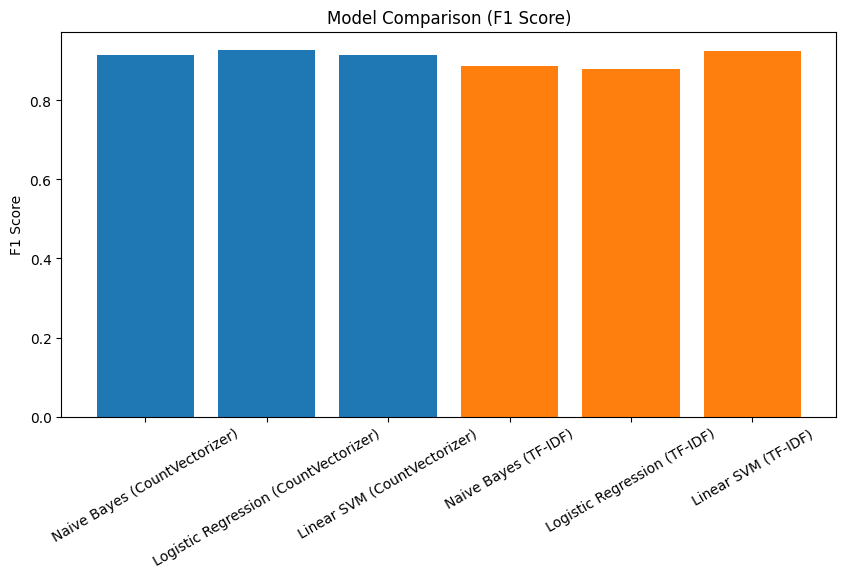

In [69]:
# Bar plot comparison

plt.figure(figsize=(10,5))

for vec in results_df['Vectorizer'].unique():
    subset = results_df[results_df['Vectorizer'] == vec]
    plt.bar(subset['Model'] + " (" + vec + ")", subset['F1 Score'])

plt.xticks(rotation=30)
plt.title("Model Comparison (F1 Score)")
plt.ylabel("F1 Score")
plt.show()

In [70]:
# Train best model again

best_model_name = best_row['Model']
best_vectorizer = best_row['Vectorizer']

model = models[best_model_name]

if best_vectorizer == 'TF-IDF':
    X_tr, X_te = X_train_tfidf, X_test_tfidf
else:
    X_tr, X_te = X_train_cv, X_test_cv

model.fit(X_tr, y_train)
y_pred = model.predict(X_te)

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))


Detailed Classification Report:
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       966
        Spam       1.00      0.87      0.93       149

    accuracy                           0.98      1115
   macro avg       0.99      0.93      0.96      1115
weighted avg       0.98      0.98      0.98      1115



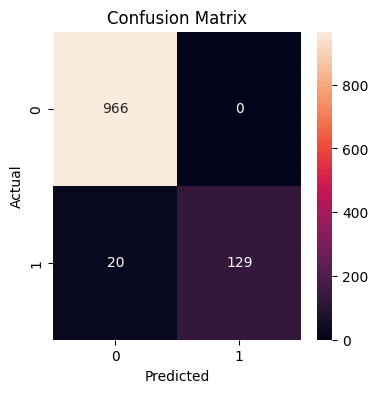

In [71]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#Sentiment Analysis

In [72]:
#  Sentiment Analysis - All approaches on spam dataset
# checking if spam messages have different sentiment patterns than ham
# spam often uses overly positive/excited language to lure people

# -----------------------------------------------------------------------
# APPROACH 1:  (no libraries)
# -----------------------------------------------------------------------
# rule-based sentiment using positive and negative word lists
# score > 0 = positive, score < 0 = negative, score = 0 = neutral

positive_words = {
    'free', 'win', 'won', 'winner', 'cash', 'prize', 'great', 'good',
    'love', 'happy', 'congratulations', 'congrats', 'excellent', 'best',
    'amazing', 'fantastic', 'offer', 'bonus', 'reward', 'gift', 'lucky'
}

negative_words = {
    'fail', 'bad', 'terrible', 'awful', 'hate', 'worst', 'disappointed',
    'problem', 'issue', 'sorry', 'wrong', 'error', 'cancel', 'stop',
    'urgent', 'warning', 'expired', 'missed', 'lose', 'lost'
}

def scratch_sentiment(text):
    tokens = manual_tokenize(text)
    score  = 0
    for word in tokens:
        if word in positive_words:
            score += 1
        elif word in negative_words:
            score -= 1

    if score > 0:
        label = 'POSITIVE'
    elif score < 0:
        label = 'NEGATIVE'
    else:
        label = 'NEUTRAL'
    return score, label

print("=== FROM SCRATCH Sentiment ===")
spam_msgs = df[df['label'] == 'spam']['message'].head(3).tolist()
ham_msgs  = df[df['label'] == 'ham']['message'].head(3).tolist()

print("\nSpam messages:")
for msg in spam_msgs:
    score, label = scratch_sentiment(msg)
    print(f"  [{label}] score={score} | {msg[:70]}")

print("\nHam messages:")
for msg in ham_msgs:
    score, label = scratch_sentiment(msg)
    print(f"  [{label}] score={score} | {msg[:70]}")

# overall sentiment distribution on full dataset
df['scratch_sentiment'] = df['message'].apply(
    lambda x: scratch_sentiment(str(x))[1]
)
print("\nScratch Sentiment Distribution:")
print(df.groupby(['label', 'scratch_sentiment']).size().unstack(fill_value=0))

# -----------------------------------------------------------------------
# APPROACH 2: WITH LIBRARY (VADER - nltk)
# -----------------------------------------------------------------------
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon', quiet=True)

vader = SentimentIntensityAnalyzer()

def vader_sentiment(text):
    scores   = vader.polarity_scores(str(text))
    compound = scores['compound']
    if compound >= 0.05:
        label = 'POSITIVE'
    elif compound <= -0.05:
        label = 'NEGATIVE'
    else:
        label = 'NEUTRAL'
    return compound, label

print("\n=== WITH LIBRARY (VADER) Sentiment ===")
print("\nSpam messages:")
for msg in spam_msgs:
    score, label = vader_sentiment(msg)
    print(f"  [{label}] compound={score:.4f} | {msg[:70]}")

print("\nHam messages:")
for msg in ham_msgs:
    score, label = vader_sentiment(msg)
    print(f"  [{label}] compound={score:.4f} | {msg[:70]}")

# overall vader sentiment distribution
df['vader_sentiment'] = df['message'].apply(
    lambda x: vader_sentiment(str(x))[1]
)
print("\nVADER Sentiment Distribution:")
print(df.groupby(['label', 'vader_sentiment']).size().unstack(fill_value=0))

# comparison: scratch vs vader
print("\nComparison - Scratch vs VADER on spam messages:")
print(f"{'Message':<45} {'Scratch':<12} {'VADER'}")
print("-" * 70)
for msg in spam_msgs:
    _, s_label = scratch_sentiment(msg)
    _, v_label = vader_sentiment(msg)
    print(f"{msg[:43]:<45} {s_label:<12} {v_label}")

# cleanup temp columns
df.drop(columns=['scratch_sentiment', 'vader_sentiment'], inplace=True)

=== FROM SCRATCH Sentiment ===

Spam messages:
  [POSITIVE] score=2 | Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Te
  [NEUTRAL] score=0 | FreeMsg Hey there darling it's been 3 week's now and no word back! I'd
  [POSITIVE] score=3 | WINNER!! As a valued network customer you have been selected to receiv

Ham messages:
  [POSITIVE] score=1 | Go until jurong point, crazy.. Available only in bugis n great world l
  [NEUTRAL] score=0 | Ok lar... Joking wif u oni...
  [NEUTRAL] score=0 | U dun say so early hor... U c already then say...

Scratch Sentiment Distribution:
scratch_sentiment  NEGATIVE  NEUTRAL  POSITIVE
label                                         
ham                     283     3920       622
spam                     82      299       366

=== WITH LIBRARY (VADER) Sentiment ===

Spam messages:
  [POSITIVE] compound=0.7964 | Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Te
  [POSITIVE] compound=0.8802 | FreeMsg Hey there darling it'

In [73]:
# Apply scratch sentiment
df['scratch_sentiment'] = df['message'].apply(scratch_sentiment)

print("\nScratch Sentiment Distribution:")
print(df.groupby(['label', 'scratch_sentiment']).size().unstack(fill_value=0))


Scratch Sentiment Distribution:
scratch_sentiment  (-3, NEGATIVE)  (-2, NEGATIVE)  (-1, NEGATIVE)  \
label                                                               
ham                             0              21             262   
spam                            1              13              68   

scratch_sentiment  (0, NEUTRAL)  (1, POSITIVE)  (2, POSITIVE)  (3, POSITIVE)  \
label                                                                          
ham                        3920            507             85             24   
spam                        299            202            108             39   

scratch_sentiment  (4, POSITIVE)  (5, POSITIVE)  (16, POSITIVE)  
label                                                            
ham                            4              1               1  
spam                          14              3               0  


In [74]:
# === BLOCK 3: VADER Sentiment ===

from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

nltk.download('vader_lexicon', quiet=True)

vader = SentimentIntensityAnalyzer()

def vader_sentiment(text):
    score = vader.polarity_scores(str(text))['compound']

    if score >= 0.05:
        return 'POSITIVE'
    elif score <= -0.05:
        return 'NEGATIVE'
    else:
        return 'NEUTRAL'

df['vader_sentiment'] = df['message'].apply(vader_sentiment)

print("\nVADER Sentiment Distribution:")
print(df.groupby(['label', 'vader_sentiment']).size().unstack(fill_value=0))


VADER Sentiment Distribution:
vader_sentiment  NEGATIVE  NEUTRAL  POSITIVE
label                                       
ham                   904     1817      2104
spam                  106       97       544


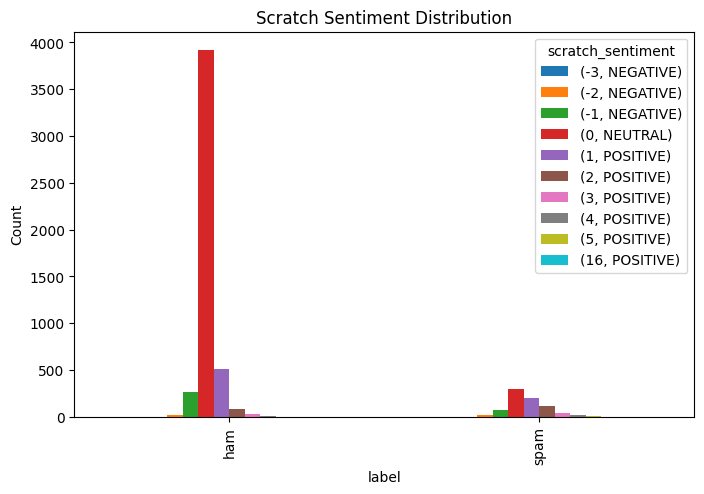

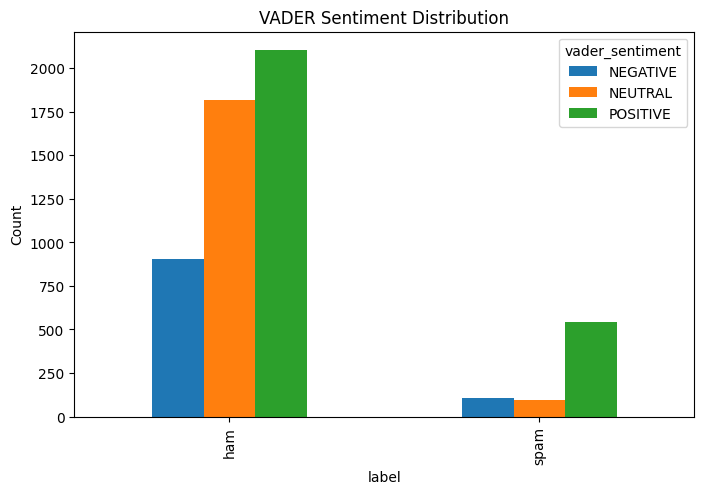

In [75]:
import matplotlib.pyplot as plt

# Scratch sentiment plot
df.groupby(['label','scratch_sentiment']).size().unstack().plot(kind='bar', figsize=(8,5))
plt.title("Scratch Sentiment Distribution")
plt.ylabel("Count")
plt.show()

# VADER sentiment plot
df.groupby(['label','vader_sentiment']).size().unstack().plot(kind='bar', figsize=(8,5))
plt.title("VADER Sentiment Distribution")
plt.ylabel("Count")
plt.show()

In [79]:
def vader_sentiment(text):
    scores = vader.polarity_scores(str(text))
    compound = scores['compound']

    if compound >= 0.05:
        return 'POSITIVE'
    elif compound <= -0.05:
        return 'NEGATIVE'
    else:
        return 'NEUTRAL'

In [80]:
print(type(vader_sentiment(msg)))

<class 'str'>


#Deep Learning Model - Dense Neural Network

In [81]:
# Convert sparse → dense safely
X_train_dl = X_train_tfidf.astype('float32').toarray()
X_test_dl  = X_test_tfidf.astype('float32').toarray()

y_train_dl = y_train.values
y_test_dl  = y_test.values

In [83]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

In [84]:
model_dl = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_dl.shape[1],)),
    BatchNormalization(),
    Dropout(0.4),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.2),

    Dense(1, activation='sigmoid')
])

In [86]:
import numpy as np

# Find indices
spam_indices = np.where(y_train_dl == 1)[0]
ham_indices  = np.where(y_train_dl == 0)[0]

# Oversample spam class
spam_oversampled = np.tile(spam_indices, len(ham_indices) // len(spam_indices) + 1)
spam_oversampled = spam_oversampled[:len(ham_indices)]

# Combine
all_indices = np.concatenate([ham_indices, spam_oversampled])

# Shuffle
np.random.seed(42)
np.random.shuffle(all_indices)

# Final balanced dataset
X_train_balanced = X_train_dl[all_indices]
y_train_balanced = y_train_dl[all_indices]

print("✅ Balanced dataset created")
print("Shape:", X_train_balanced.shape)

✅ Balanced dataset created
Shape: (7718, 3000)


In [89]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',   # track validation loss
    patience=3,           # stop after 3 epochs of no improvement
    restore_best_weights=True
)

In [92]:
model_dl.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [93]:
history = model_dl.fit(
    X_train_balanced, y_train_balanced,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 0.9034 - loss: 0.2089 - val_accuracy: 0.4987 - val_loss: 0.5732
Epoch 2/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9937 - loss: 0.0239 - val_accuracy: 0.5285 - val_loss: 0.5016
Epoch 3/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9983 - loss: 0.0102 - val_accuracy: 0.9210 - val_loss: 0.2729
Epoch 4/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9980 - loss: 0.0078 - val_accuracy: 0.9948 - val_loss: 0.0807
Epoch 5/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9983 - loss: 0.0090 - val_accuracy: 0.9974 - val_loss: 0.0169
Epoch 6/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9978 - loss: 0.0085 - val_accuracy: 0.9961 - val_loss: 0.0112
Epoch 7/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9987 - loss: 0.0062 - val_accuracy: 0.9961 - val_loss: 0.0128
Epoch 8/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9988 - loss: 0.0049 - val_accuracy: 

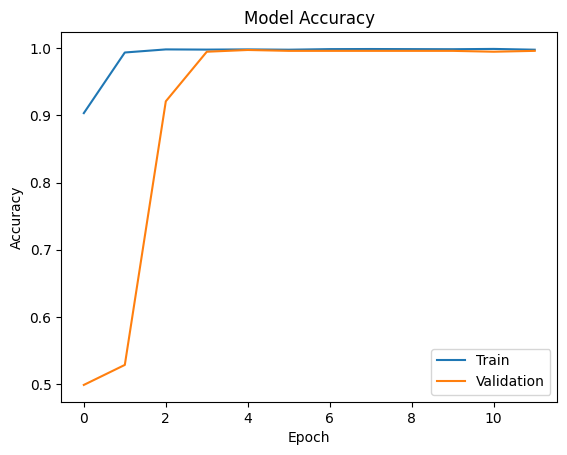

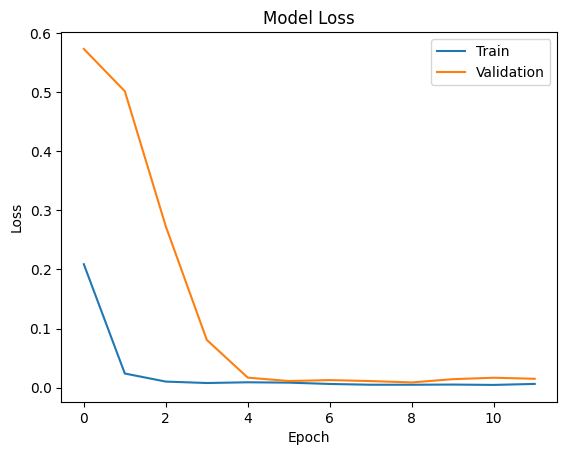

In [94]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(['Train', 'Validation'])
plt.show()

# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(['Train', 'Validation'])
plt.show()

In [95]:
y_pred_prob = model_dl.predict(X_test_dl, verbose=0)

# Try slightly stricter threshold (optional improvement)
y_pred_dl = (y_pred_prob >= 0.5).astype(int).flatten()

In [96]:
from sklearn.metrics import confusion_matrix

dl_acc = accuracy_score(y_test_dl, y_pred_dl)
dl_f1  = f1_score(y_test_dl, y_pred_dl)

print("\nDeep Learning Results:")
print(f"Accuracy : {dl_acc:.4f}")
print(f"F1 Score : {dl_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_dl, y_pred_dl, target_names=['Ham', 'Spam']))


Deep Learning Results:
Accuracy : 0.9830
F1 Score : 0.9338

Classification Report:
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       966
        Spam       0.97      0.90      0.93       149

    accuracy                           0.98      1115
   macro avg       0.98      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



In [97]:
from sklearn.metrics import confusion_matrix

dl_acc = accuracy_score(y_test_dl, y_pred_dl)
dl_f1  = f1_score(y_test_dl, y_pred_dl)

print("\nDeep Learning Results:")
print(f"Accuracy : {dl_acc:.4f}")
print(f"F1 Score : {dl_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_dl, y_pred_dl, target_names=['Ham', 'Spam']))


Deep Learning Results:
Accuracy : 0.9830
F1 Score : 0.9338

Classification Report:
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       966
        Spam       0.97      0.90      0.93       149

    accuracy                           0.98      1115
   macro avg       0.98      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



#  Confusion Matrix for all models

In [98]:
y_test_list = y_test.tolist()
y_test_dl_list = y_test_dl.tolist()

In [99]:
# Manual NB
y_pred_manual_nb = mnb.predict(X_test.tolist())

# Sklearn NB
nb_model = MultinomialNB()
nb_model.fit(X_train_cv, y_train)
y_pred_nb_cv = nb_model.predict(X_test_cv)

# Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_cv, y_train)
y_pred_lr_cv = lr_model.predict(X_test_cv)

# SVM
svm_model_cv = LinearSVC(random_state=42, max_iter=1000)
svm_model_cv.fit(X_train_cv, y_train)
y_pred_svm_cv = svm_model_cv.predict(X_test_cv)

# Deep Learning
y_pred_prob_dl = model_dl.predict(X_test_dl, verbose=0)
y_pred_dl_final = (y_pred_prob_dl >= 0.5).astype(int).flatten()

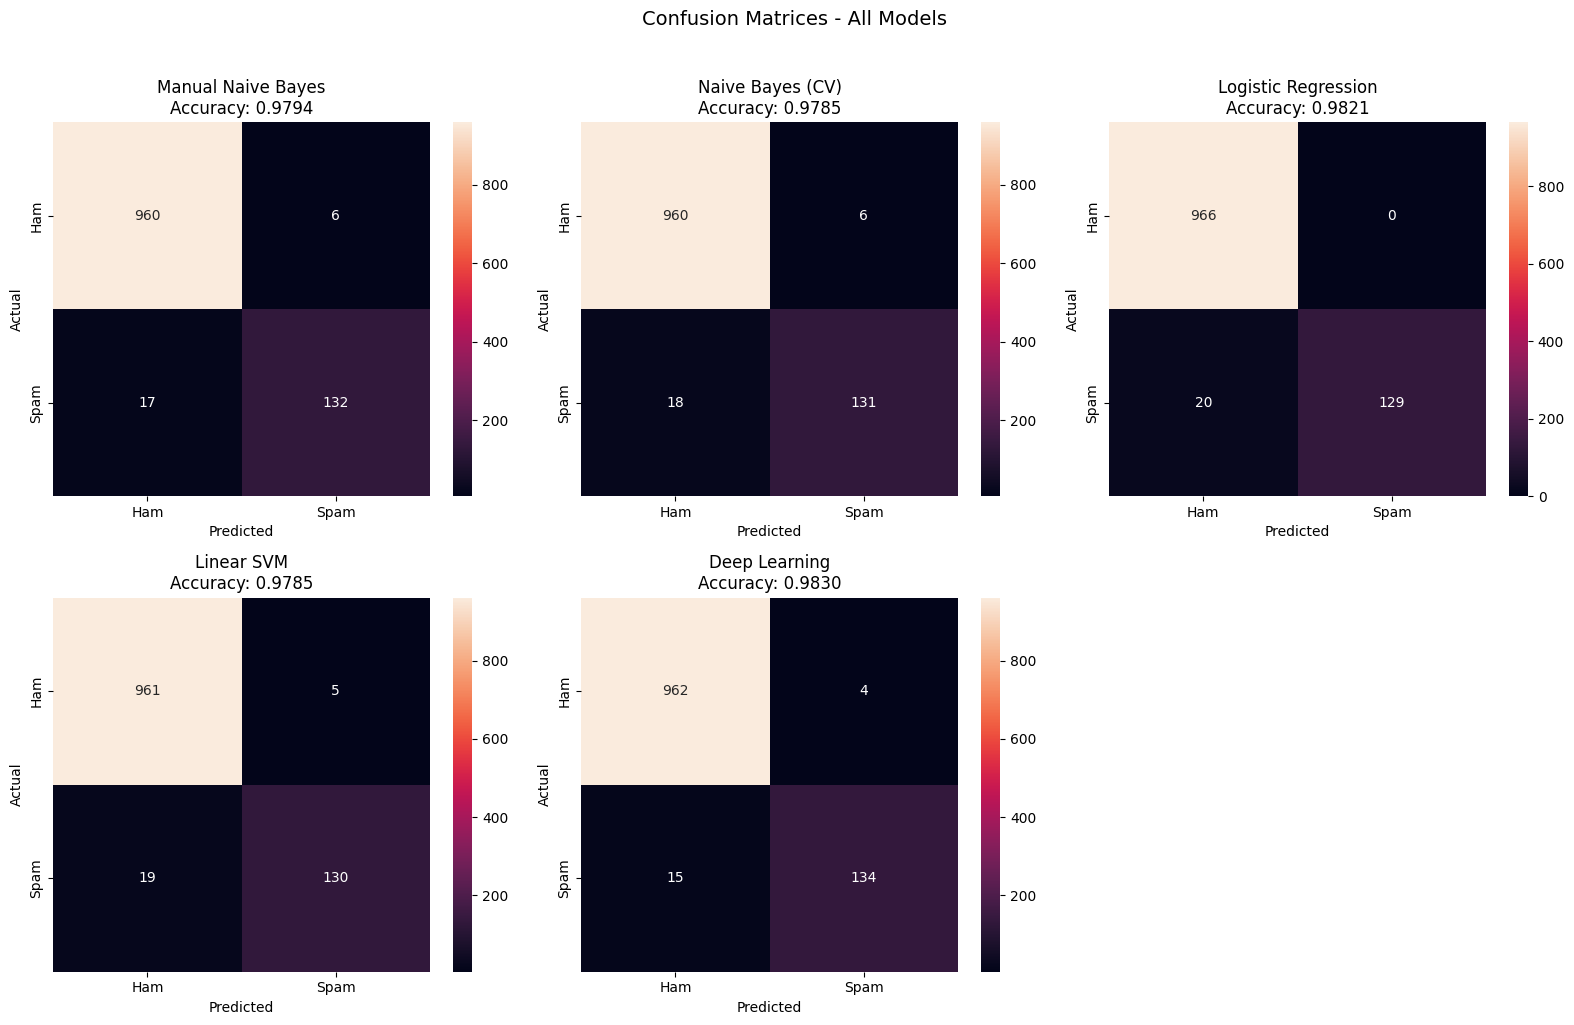

In [100]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

predictions = [
    (y_pred_manual_nb,  y_test_list,    'Manual Naive Bayes'),
    (y_pred_nb_cv,      y_test_list,    'Naive Bayes (CV)'),
    (y_pred_lr_cv,      y_test_list,    'Logistic Regression'),
    (y_pred_svm_cv,     y_test_list,    'Linear SVM'),
    (y_pred_dl_final,   y_test_dl_list, 'Deep Learning'),
]

for i, (y_pred, y_true, title) in enumerate(predictions):

    cm = confusion_matrix(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        ax=axes[i],
        xticklabels=['Ham', 'Spam'],
        yticklabels=['Ham', 'Spam']
    )

    axes[i].set_title(f"{title}\nAccuracy: {acc:.4f}")
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

# Hide empty subplot
axes[5].set_visible(False)

plt.suptitle('Confusion Matrices - All Models', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [101]:
# Use results from previous models instead of hardcoding
results_df = pd.DataFrame(results)

# convert to percentage
results_df['Accuracy'] = (results_df['Accuracy'] * 100).round(2)
results_df['F1 Score'] = (results_df['F1 Score'] * 100).round(2)

In [103]:
labels = results_df.apply(
    lambda r: f"{r['Model']}\n({r['Vectorizer']})", axis=1
)

accuracies = results_df['Accuracy'].values
f1_scores  = results_df['F1 Score'].values

x = np.arange(len(labels))
width = 0.35

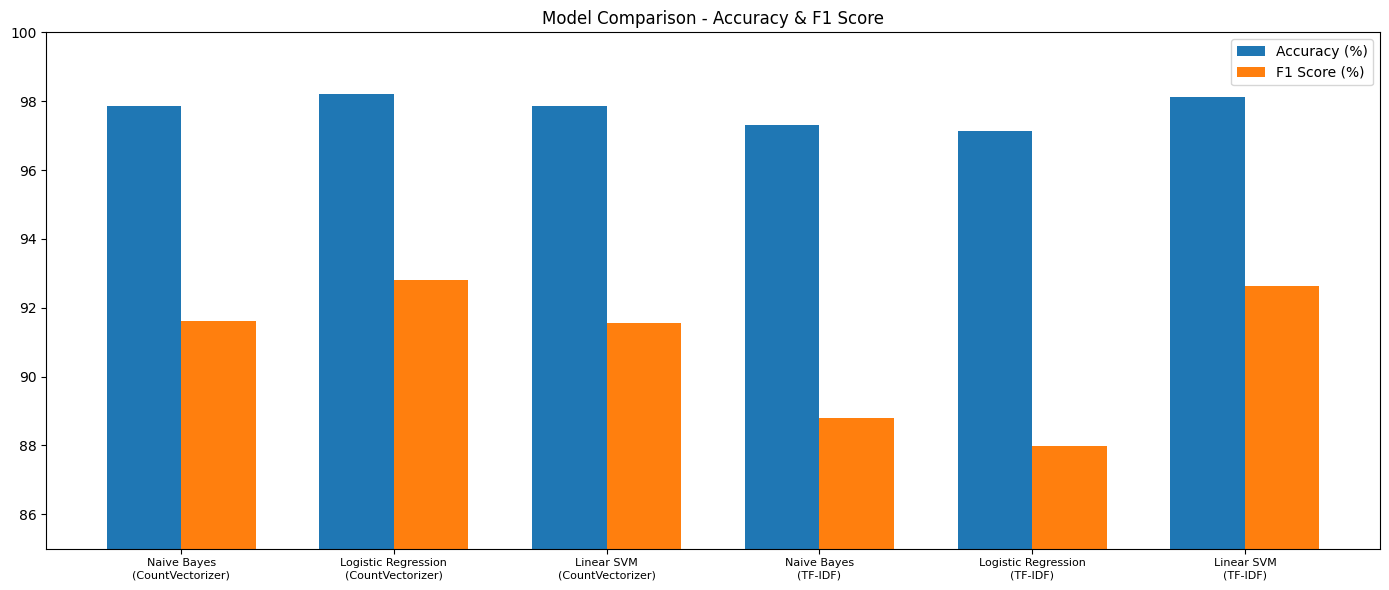

In [106]:
fig, ax = plt.subplots(figsize=(14, 6))

bars1 = ax.bar(x - width/2, accuracies, width, label='Accuracy (%)')
bars2 = ax.bar(x + width/2, f1_scores,  width, label='F1 Score (%)')

ax.set_title('Model Comparison - Accuracy & F1 Score')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylim(85, 100)
ax.legend()

plt.tight_layout()
plt.show()

In [107]:
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.1,
                 f'{bar.get_height():.1f}',
                 ha='center', fontsize=7)

for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.1,
                 f'{bar.get_height():.1f}',
                 ha='center', fontsize=7)

In [108]:
axes[1].axis('off')

table_data = results_df[['Model','Vectorizer','Accuracy','F1 Score']].values

table = axes[1].table(
    cellText=table_data,
    colLabels=['Model','Vectorizer','Accuracy','F1 Score'],
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.8)

# ✅ find best model dynamically
best_idx = results_df['F1 Score'].idxmax()

for j in range(4):
    table[best_idx + 1, j].set_facecolor('#d4edda')  # +1 because header row

axes[1].set_title('Summary Table (Best Model Highlighted)', pad=20)

Text(0.5, 1.0, 'Summary Table (Best Model Highlighted)')

In [109]:
plt.tight_layout()
plt.show()

print("\nFinal Results:")
print(results_df.to_string(index=False))

<Figure size 640x480 with 0 Axes>


Final Results:
              Model      Vectorizer  Accuracy  F1 Score
        Naive Bayes CountVectorizer     97.85     91.61
Logistic Regression CountVectorizer     98.21     92.81
         Linear SVM CountVectorizer     97.85     91.55
        Naive Bayes          TF-IDF     97.31     88.81
Logistic Regression          TF-IDF     97.13     87.97
         Linear SVM          TF-IDF     98.12     92.63
